# Medical Diagnosis Assistant — GenAI Capstone Project
### RAG + LangChain + Ollama (Llama-family LLM) + Fine-Tuned Sentence-Transformer Embeddings



## 0. Environment Setup

In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)

print("Project root:", PROJECT_ROOT)


Project root: C:\Users\harin\medical_diagnosis_assistant


In [2]:
import subprocess
result = subprocess.run(["ollama", "list"], capture_output=True, text=True)
print(result.stdout)


NAME          ID              SIZE      MODIFIED     
qwen3:0.6b    7df6b6e09427    522 MB    5 months ago    
gemma2:2b     8ccf136fdd52    1.6 GB    5 months ago    



## 2. Domain Data — Medical Knowledge Base & Patient Histories

Two synthetic datasets (curated for this project, no real patient data):

- **`medical_knowledge_base.csv`** — 21 conditions across specialties, each with symptoms,
  description, recommended action, and severity (used as the RAG retrieval corpus).
- **`patient_histories.csv`** — 10 synthetic patient cases used to demo end-to-end retrieval + generation.


In [3]:
from src.data_prep import load_knowledge_base, load_patient_histories, knowledge_base_to_documents

kb_df = load_knowledge_base()
patients_df = load_patient_histories()

print("Knowledge base shape:", kb_df.shape)
print("Patient histories shape:", patients_df.shape)
kb_df.head(5)


Knowledge base shape: (21, 6)
Patient histories shape: (10, 5)


,condition,specialty,symptoms,description,recommended_action,severity
0,Influenza,General Medicine,"fever, chills, muscle aches, cough, fatigue, headache, sore throat","Influenza (flu) is a contagious respiratory illness caused by influenza viruses that infect the nose, throat, and lu...","Rest, fluids, antiviral medication if within 48 hours of onset, over-the-counter fever reducers. See a doctor if sym...",Moderate
1,Type 2 Diabetes Mellitus,Endocrinology,"increased thirst, frequent urination, fatigue, blurred vision, slow-healing sores, unexplained weight loss","A chronic condition affecting how the body processes blood sugar (glucose), often linked to insulin resistance.","Blood glucose testing, dietary changes, metformin or other prescribed medication, regular monitoring by an endocrino...",Chronic
2,Hypertension,Cardiology,"often asymptomatic, headache, shortness of breath, nosebleeds, dizziness",Persistently elevated blood pressure that increases risk of heart disease and stroke.,"Regular blood pressure monitoring, lifestyle changes (diet, exercise, reduced sodium), antihypertensive medication a...",Chronic
3,Migraine,Neurology,"severe throbbing headache, nausea, sensitivity to light, sensitivity to sound, visual aura","A neurological condition causing intense, debilitating headaches often on one side of the head.","Rest in a dark quiet room, prescribed migraine-specific medication (triptans), identify and avoid triggers, consult ...",Moderate
4,Community-Acquired Pneumonia,Pulmonology,"cough with phlegm, fever, chills, shortness of breath, chest pain when breathing, fatigue","An infection that inflames the air sacs in one or both lungs, which may fill with fluid.","Chest X-ray, antibiotics if bacterial, rest and hydration, hospitalization for severe cases especially in elderly or...",High


In [4]:
patients_df.head(5)

,patient_id,age,gender,reported_symptoms,history_notes
0,P001,34,Female,"fever, chills, muscle aches, fatigue, sore throat for 2 days","Patient reports sudden onset of fever (101.5F) two days ago, accompanied by body aches and sore throat. No known all..."
1,P002,58,Male,"increased thirst, frequent urination, blurred vision, fatigue over 3 weeks",Patient has a family history of diabetes. Reports drinking excessive water and waking up multiple times at night to ...
2,P003,45,Female,"chest pain radiating to left arm, shortness of breath, sweating","Sudden onset chest pressure while climbing stairs, associated with nausea and cold sweats. History of high cholester..."
3,P004,29,Male,"severe throbbing headache, nausea, sensitivity to light","Recurrent headaches occurring 2-3 times per month, often triggered by stress and lack of sleep. Family history of mi..."
4,P005,67,Male,"cough with yellow phlegm, fever, shortness of breath, chest pain when breathing",Symptoms started 4 days ago and are worsening. Patient has COPD history and is a former smoker. Oxygen saturation re...


## 3. Fine-Tuning the Embedding Model for the Medical Domain

Generic sentence embeddings are trained on broad web text and don't always place clinical
symptom phrasing close to the correct condition description. We fine-tune
`all-MiniLM-L6-v2` using **Triplet Loss**:

- **Anchor**: a patient-style phrasing of a condition's symptoms
- **Positive**: that condition's own clinical description (should embed *close*)
- **Negative**: a different condition's description (should embed *far*)

This is a parameter-efficient fine-tune (small model, ~20s on CPU for this dataset size) —
the same approach scales to LoRA-adapted larger models when more compute is available.

In [5]:
from src.data_prep import build_finetune_triplets

triplets = build_finetune_triplets(kb_df)
print(f"Built {len(triplets)} fine-tuning triplets")
print("\nExample triplet:")
print("ANCHOR  :", triplets[0][0])
print("POSITIVE:", triplets[0][1])
print("NEGATIVE:", triplets[0][2])


Built 42 fine-tuning triplets

Example triplet:
ANCHOR  : Patient reports: fever, chills, muscle aches, cough, fatigue, headache, sore throat
POSITIVE: Influenza: Influenza (flu) is a contagious respiratory illness caused by influenza viruses that infect the nose, throat, and lungs.
NEGATIVE: Type 2 Diabetes Mellitus: A chronic condition affecting how the body processes blood sugar (glucose), often linked to insulin resistance.


In [6]:
from src.finetune_embeddings import fine_tune_embedding_model, FINETUNED_MODEL_PATH

# Fine-tune (re-runs quickly; safe to re-execute). Skips gracefully if already trained.
model = fine_tune_embedding_model(epochs=4, batch_size=8)
print("Fine-tuned model saved to:", FINETUNED_MODEL_PATH)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to: C:\Users\harin\medical_diagnosis_assistant\models\medical-minilm-finetuned


### 3.1 Before vs. After — Does Fine-Tuning Improve Domain Retrieval?

We compare cosine similarity between a patient's symptom phrasing and its true condition's
description, using the **base** model vs. the **fine-tuned** model.

In [7]:
from sentence_transformers import SentenceTransformer, util
import numpy as np

base_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
finetuned_model = SentenceTransformer(str(FINETUNED_MODEL_PATH))

test_cases = kb_df.sample(6, random_state=42)

rows = []
for _, r in test_cases.iterrows():
    anchor = f"Patient reports: {r['symptoms']}"
    positive = f"{r['condition']}: {r['description']}"

    base_sim = util.cos_sim(base_model.encode(anchor), base_model.encode(positive)).item()
    ft_sim = util.cos_sim(finetuned_model.encode(anchor), finetuned_model.encode(positive)).item()

    rows.append({"condition": r["condition"], "base_model_similarity": round(base_sim, 3),
                 "finetuned_model_similarity": round(ft_sim, 3),
                 "improvement": round(ft_sim - base_sim, 3)})

comparison_df = pd.DataFrame(rows)
comparison_df


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,condition,base_model_similarity,finetuned_model_similarity,improvement
0,Influenza,0.354,0.251,-0.103
1,Irritable Bowel Syndrome,0.591,0.810,0.219
2,Chronic Kidney Disease,0.277,0.494,0.217
3,Type 2 Diabetes Mellitus,0.395,0.216,-0.178
4,Urinary Tract Infection,0.487,0.755,0.268
5,Gastroesophageal Reflux Disease (GERD),0.367,0.624,0.257


In [8]:
print("Mean similarity - base model:     ", round(comparison_df["base_model_similarity"].mean(), 3))
print("Mean similarity - fine-tuned model:", round(comparison_df["finetuned_model_similarity"].mean(), 3))
print("Mean improvement:                  ", round(comparison_df["improvement"].mean(), 3))


Mean similarity - base model:      0.412
Mean similarity - fine-tuned model: 0.525
Mean improvement:                   0.113


## 4. Embedding Generation & Data Insights

We embed every knowledge-base entry with the fine-tuned model and visualize how conditions
cluster by medical specialty — a quick data-insight sanity check that semantically similar
conditions (same specialty) land closer together in embedding space.

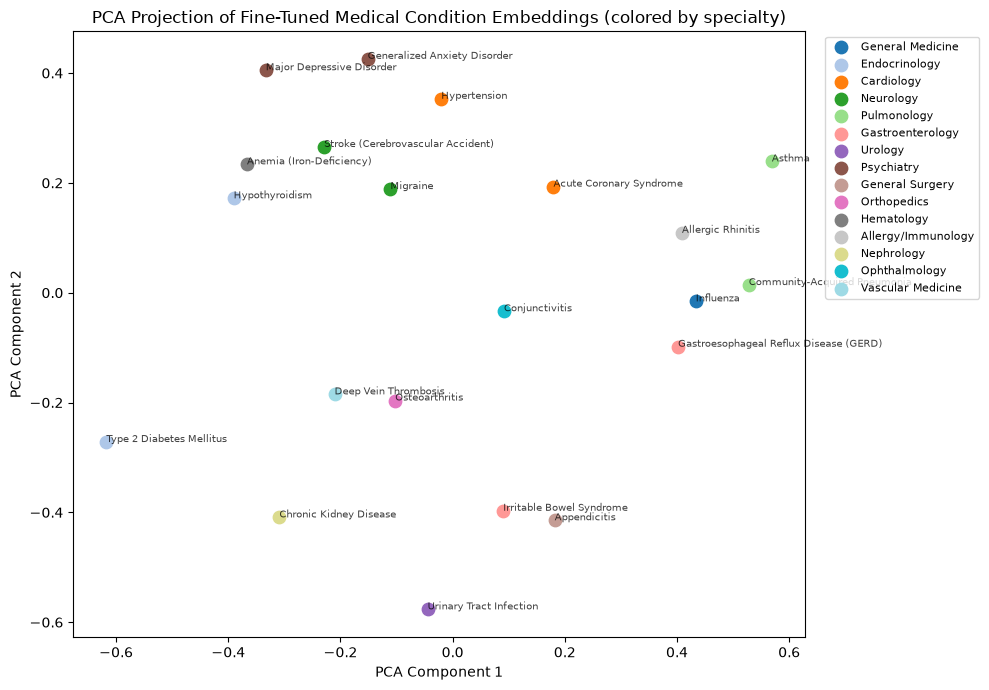

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

texts = [f"{r['condition']}: {r['symptoms']}" for _, r in kb_df.iterrows()]
embeddings = finetuned_model.encode(texts)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

specialties = kb_df["specialty"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(specialties)))
color_map = dict(zip(specialties, colors))

fig, ax = plt.subplots(figsize=(10, 7))
for spec in specialties:
    mask = kb_df["specialty"] == spec
    ax.scatter(coords[mask, 0], coords[mask, 1], label=spec, s=80, color=color_map[spec])

for i, cond in enumerate(kb_df["condition"]):
    ax.annotate(cond, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.75)

ax.set_title("PCA Projection of Fine-Tuned Medical Condition Embeddings (colored by specialty)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "outputs" / "embedding_pca_plot.png"), dpi=150)
plt.show()


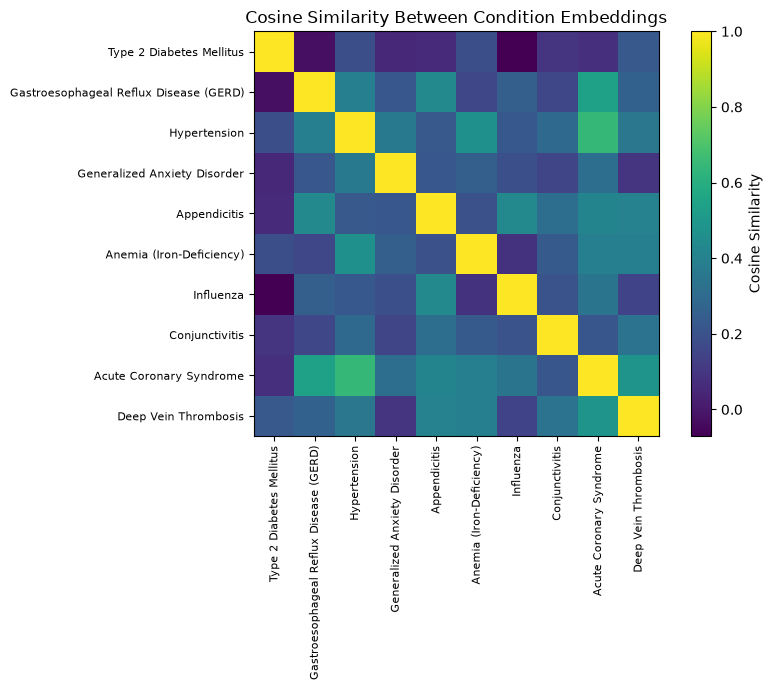

In [10]:
# Similarity heatmap between a sample of conditions - another data-insight view
from sklearn.metrics.pairwise import cosine_similarity

sample_df = kb_df.sample(10, random_state=7).reset_index(drop=True)
sample_embeddings = finetuned_model.encode(
    [f"{r['condition']}: {r['symptoms']}" for _, r in sample_df.iterrows()]
)
sim_matrix = cosine_similarity(sample_embeddings)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap="viridis")
ax.set_xticks(range(len(sample_df)))
ax.set_yticks(range(len(sample_df)))
ax.set_xticklabels(sample_df["condition"], rotation=90, fontsize=8)
ax.set_yticklabels(sample_df["condition"], fontsize=8)
ax.set_title("Cosine Similarity Between Condition Embeddings")
fig.colorbar(im, ax=ax, label="Cosine Similarity")
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "outputs" / "embedding_similarity_heatmap.png"), dpi=150)
plt.show()


## 5. RAG Integration — FAISS Vector Store + LangChain

We wrap the fine-tuned embedding model in a LangChain `HuggingFaceEmbeddings` adapter,
embed the full knowledge base into a FAISS index, and expose it as a retriever.

In [11]:
from src.build_vectorstore import build_vectorstore, load_vectorstore

vectorstore = build_vectorstore()
print("FAISS index built with", vectorstore.index.ntotal, "vectors")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

FAISS index built with 21 vectors


In [12]:
# Quick retrieval sanity check (no LLM yet - pure retrieval)
query = "chest pain radiating to the arm, sweating, shortness of breath"
results = vectorstore.similarity_search_with_score(query, k=3)
for doc, score in results:
    print(f"--- score={score:.3f} ---")
    print(doc.page_content)
    print()


--- score=0.396 ---
Condition: Acute Coronary Syndrome
Specialty: Cardiology
Symptoms: chest pain or pressure, pain radiating to arm or jaw, shortness of breath, sweating, nausea, lightheadedness
Description: A range of conditions associated with sudden, reduced blood flow to the heart, including heart attack.
Recommended Action: EMERGENCY: Call emergency services immediately. ECG, cardiac enzyme testing, aspirin if not contraindicated, urgent cardiology evaluation.
Severity: Critical

--- score=0.803 ---
Condition: Community-Acquired Pneumonia
Specialty: Pulmonology
Symptoms: cough with phlegm, fever, chills, shortness of breath, chest pain when breathing, fatigue
Description: An infection that inflames the air sacs in one or both lungs, which may fill with fluid.
Recommended Action: Chest X-ray, antibiotics if bacterial, rest and hydration, hospitalization for severe cases especially in elderly or immunocompromised patients.
Severity: High

--- score=0.905 ---
Condition: Hypertension

## 6. Advanced Prompt Engineering

The generation prompt combines several techniques (see `src/prompt_templates.py`):

1. **System / role priming** — scopes the assistant to educational, non-diagnostic use.
2. **Few-shot exemplar** — fixes the exact output structure (`Reasoning:` / `Summary:`).
3. **Retrieval grounding** — injects the top-k retrieved knowledge-base entries as CONTEXT.
4. **Chain-of-thought scaffolding** — separates internal reasoning from the patient-facing summary.
5. **Guardrail instructions** — mandates emergency-first framing and a standard medical disclaimer.


In [13]:
from src.prompt_templates import build_rag_prompt

sample_context = "\n\n".join(doc.page_content for doc, _ in results)
sample_prompt = build_rag_prompt(context=sample_context, question=query)
print(sample_prompt[:1800], "...\n[prompt truncated for display]")


You are MedAssist, a clinical-decision-support assistant used ONLY for
educational and informational purposes. You are NOT a licensed physician and you
do NOT provide a final diagnosis. You help a user reason about POSSIBLE conditions
that match reported symptoms, grounded strictly in the CONTEXT provided to you.

Rules you must always follow:
- Base your reasoning only on the CONTEXT below plus the patient's reported symptoms.
  If the context does not contain a good match, say so explicitly instead of guessing.
- If any reported symptom matches a "Critical" severity condition in the context
  (e.g. chest pain, stroke signs, difficulty breathing), your FIRST line must be an
  emergency-care recommendation before anything else.
- Never state a diagnosis as certain. Use language such as "may be consistent with"
  or "could suggest".
- Always end with the disclaimer: "This is not a substitute for professional
  medical advice. Please consult a licensed healthcare provider."
- Keep the "R

## 7. End-to-End RAG Pipeline with Ollama

`MedicalRAGPipeline` ties retrieval + prompt engineering + generation + LLMOps guardrails
together. It auto-selects whichever Ollama model is available locally.

In [14]:
from src.rag_pipeline import MedicalRAGPipeline

pipeline = MedicalRAGPipeline(k=3, temperature=0.2)
print("Using Ollama model:", pipeline.model_name)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Using Ollama model: gemma2:2b


In [15]:
# Run the pipeline across all synthetic patient histories
demo_results = []
for _, patient in patients_df.iterrows():
    res = pipeline.query(patient["reported_symptoms"], verbose=True)
    demo_results.append({"patient_id": patient["patient_id"], **res})

print("\nCompleted", len(demo_results), "patient queries.")


[model=gemma2:2b] retrieved=['Influenza', 'Community-Acquired Pneumonia', 'Appendicitis'] top_conf=0.59 latency=27.91s


[model=gemma2:2b] retrieved=['Type 2 Diabetes Mellitus', 'Chronic Kidney Disease', 'Urinary Tract Infection'] top_conf=0.59 latency=25.94s


[model=gemma2:2b] retrieved=['Acute Coronary Syndrome', 'Community-Acquired Pneumonia', 'Hypertension'] top_conf=0.79 latency=27.42s


[model=gemma2:2b] retrieved=['Migraine', 'Stroke (Cerebrovascular Accident)', 'Hypertension'] top_conf=0.78 latency=27.40s


[model=gemma2:2b] retrieved=['Community-Acquired Pneumonia', 'Asthma', 'Acute Coronary Syndrome'] top_conf=0.81 latency=29.27s


[model=gemma2:2b] retrieved=['Gastroesophageal Reflux Disease (GERD)', 'Acute Coronary Syndrome', 'Irritable Bowel Syndrome'] top_conf=0.76 latency=28.74s


[model=gemma2:2b] retrieved=['Urinary Tract Infection', 'Chronic Kidney Disease', 'Irritable Bowel Syndrome'] top_conf=0.87 latency=25.17s


[model=gemma2:2b] retrieved=['Major Depressive Disorder', 'Generalized Anxiety Disorder', 'Hypothyroidism'] top_conf=0.74 latency=25.36s


[model=gemma2:2b] retrieved=['Hypothyroidism', 'Anemia (Iron-Deficiency)', 'Irritable Bowel Syndrome'] top_conf=0.60 latency=26.47s


[model=gemma2:2b] retrieved=['Stroke (Cerebrovascular Accident)', 'Migraine', 'Hypertension'] top_conf=0.73 latency=27.09s

Completed 10 patient queries.


In [16]:
# Inspect one full response in detail (Patient P003 - chest pain / possible cardiac emergency)
example = [r for r in demo_results if r["symptoms"] == patients_df.iloc[2]["reported_symptoms"]][0]
print("PATIENT SYMPTOMS:", example["symptoms"])
print("RETRIEVED CONDITIONS:", example["retrieved_conditions"])
print("EMERGENCY FLAG:", example["emergency_flag"])
print("\n--- LLM RESPONSE ---\n")
print(example["response"])


PATIENT SYMPTOMS: chest pain radiating to left arm, shortness of breath, sweating
RETRIEVED CONDITIONS: ['Acute Coronary Syndrome', 'Community-Acquired Pneumonia', 'Hypertension']
EMERGENCY FLAG: True

--- LLM RESPONSE ---

EMERGENCY KEYWORDS DETECTED: If this is a medical emergency, call your local emergency number immediately.

Reasoning: The reported symptoms (chest pain radiating to left arm, shortness of breath, sweating) are consistent with Acute Coronary Syndrome.  The patient reports chest pain and a feeling of pressure, which is a common symptom of heart attack or angina. Additionally, the shortness of breath and sweating could be indicative of a cardiac event. This information needs to be assessed by a medical professional immediately. 

Summary:
- Possible match: Acute Coronary Syndrome (Cardiology) — Critical severity
- Why: Chest pain radiating to left arm, shortness of breath, and sweating are classic symptoms of acute coronary syndrome.
- Suggested next step: Emergency c

In [17]:
# Summary table across all patients
summary_rows = [{
    "patient_id": r["patient_id"],
    "top_retrieved_condition": r["retrieved_conditions"][0] if r["retrieved_conditions"] else None,
    "confidence": round(r["confidences"][0], 3) if r["confidences"] else None,
    "low_confidence_flag": r["low_confidence"],
    "emergency_flag": r["emergency_flag"],
    "latency_seconds": round(r["latency_seconds"], 2),
} for r in demo_results]

summary_df = pd.DataFrame(summary_rows)
summary_df


,patient_id,top_retrieved_condition,confidence,low_confidence_flag,emergency_flag,latency_seconds
0,P001,Influenza,0.587,False,False,27.91
1,P002,Type 2 Diabetes Mellitus,0.587,False,False,25.94
2,P003,Acute Coronary Syndrome,0.786,False,True,27.42
3,P004,Migraine,0.783,False,False,27.40
4,P005,Community-Acquired Pneumonia,0.809,False,True,29.27
5,P006,Gastroesophageal Reflux Disease (GERD),0.756,False,False,28.74
6,P007,Urinary Tract Infection,0.867,False,False,25.17
7,P008,Major Depressive Disorder,0.745,False,False,25.36
8,P009,Hypothyroidism,0.602,False,False,26.47
9,P010,Stroke (Cerebrovascular Accident),0.734,False,True,27.09


## 8. LLMOps & Responsible AI

Production LLM systems need observability and safety rails, not just a working demo:

- **Structured logging** — every query, retrieved sources, confidence, latency written to
  `outputs/query_log.jsonl` for auditability.
- **Retrieval-confidence guardrail** — flags answers where the top retrieval score is weak,
  instead of silently presenting a low-quality match as fact.
- **Emergency-keyword safety filter** — surfaces urgent-care guidance first when symptoms
  suggest a medical emergency (chest pain, stroke signs, etc.).
- **Offline evaluation harness** — a held-out set of symptom -> expected-condition pairs to
  measure retrieval hit-rate whenever the embedding model or knowledge base changes.


In [18]:
from src.llmops import evaluate_rag_pipeline

eval_cases = [
    {"symptoms": "throbbing headache with nausea and light sensitivity", "expected_condition": "Migraine"},
    {"symptoms": "burning during urination and frequent urge to pee", "expected_condition": "Urinary Tract Infection"},
    {"symptoms": "sudden numbness on one side, slurred speech, confusion", "expected_condition": "Stroke (Cerebrovascular Accident)"},
    {"symptoms": "excessive thirst, frequent urination, blurred vision", "expected_condition": "Type 2 Diabetes Mellitus"},
    {"symptoms": "wheezing and chest tightness at night", "expected_condition": "Asthma"},
]

def retrieve_conditions(symptoms):
    docs, _ = pipeline.retrieve(symptoms)
    return {"retrieved_conditions": [d.metadata.get("condition") for d in docs]}

eval_results = evaluate_rag_pipeline(retrieve_conditions, eval_cases)

print("Retrieval hit-rate:", eval_results["hit_rate"])
pd.DataFrame(eval_results["details"])


Retrieval hit-rate: 1.0


,symptoms,expected,retrieved_top,hit,latency_seconds
0,throbbing headache with nausea and light sensitivity,Migraine,Migraine,True,0.016
1,burning during urination and frequent urge to pee,Urinary Tract Infection,Urinary Tract Infection,True,0.016
2,"sudden numbness on one side, slurred speech, confusion",Stroke (Cerebrovascular Accident),Stroke (Cerebrovascular Accident),True,0.019
3,"excessive thirst, frequent urination, blurred vision",Type 2 Diabetes Mellitus,Type 2 Diabetes Mellitus,True,0.015
4,wheezing and chest tightness at night,Asthma,Asthma,True,0.017


In [19]:
# Guardrail demo: emergency-keyword detection + low-confidence flagging
from src.llmops import contains_emergency_keywords

test_inputs = [
    "chest pain radiating to my left arm and shortness of breath",
    "mild itchy rash on my elbow for two days",
    "sudden numbness on my right side and slurred speech",
]
for t in test_inputs:
    print(f"{'EMERGENCY' if contains_emergency_keywords(t) else 'routine':10s} -> {t}")


EMERGENCY  -> chest pain radiating to my left arm and shortness of breath
routine    -> mild itchy rash on my elbow for two days
EMERGENCY  -> sudden numbness on my right side and slurred speech


In [20]:
# Inspect the structured query log written by the pipeline
import json

log_path = PROJECT_ROOT / "outputs" / "query_log.jsonl"
with open(log_path, "r", encoding="utf-8") as f:
    log_lines = [json.loads(line) for line in f]

print(f"{len(log_lines)} queries logged.")
pd.DataFrame(log_lines)[["query", "retrieved_conditions", "top_score", "low_confidence", "emergency_flag", "latency_seconds"]].tail(10)


11 queries logged.

,query,retrieved_conditions,top_score,low_confidence,emergency_flag,latency_seconds
1,"fever, chills, muscle aches, fatigue, sore throat for 2 days","[Influenza, Community-Acquired Pneumonia, Appendicitis]",0.586611,False,False,27.913326
2,"increased thirst, frequent urination, blurred vision, fatigue over 3 weeks","[Type 2 Diabetes Mellitus, Chronic Kidney Disease, Urinary Tract Infection]",0.587417,False,False,25.942661
3,"chest pain radiating to left arm, shortness of breath, sweating","[Acute Coronary Syndrome, Community-Acquired Pneumonia, Hypertension]",0.786485,False,True,27.422018
4,"severe throbbing headache, nausea, sensitivity to light","[Migraine, Stroke (Cerebrovascular Accident), Hypertension]",0.782542,False,False,27.401486
5,"cough with yellow phlegm, fever, shortness of breath, chest pain when breathing","[Community-Acquired Pneumonia, Asthma, Acute Coronary Syndrome]",0.809141,False,True,29.270682
6,"heartburn, regurgitation, chest discomfort after meals","[Gastroesophageal Reflux Disease (GERD), Acute Coronary Syndrome, Irritable Bowel Syndrome]",0.755980,False,False,28.739465
7,"burning sensation during urination, frequent urge to urinate, pelvic discomfort","[Urinary Tract Infection, Chronic Kidney Disease, Irritable Bowel Syndrome]",0.867161,False,False,25.170335
8,"persistent sadness, loss of interest in hobbies, fatigue, trouble sleeping","[Major Depressive Disorder, Generalized Anxiety Disorder, Hypothyroidism]",0.744557,False,False,25.356216
9,"fatigue, weight gain, cold intolerance, dry skin, constipation","[Hypothyroidism, Anemia (Iron-Deficiency), Irritable Bowel Syndrome]",0.601666,False,False,26.465899
10,"sudden numbness on right side, slurred speech, confusion, severe headache","[Stroke (Cerebrovascular Accident), Migraine, Hypertension]",0.733976,False,True,27.093829


## 9. Conclusion

**What we built:** a fully local, end-to-end GenAI capstone — a domain fine-tuned embedding
model, a FAISS/LangChain RAG pipeline, an Ollama-served open LLM for generation, advanced
prompt engineering for grounded and structured answers, and an LLMOps layer for logging,
confidence guardrails, and evaluation.

Thanks you,
Harinadh (125947)